# Notebook eye/03 — Custom CNN Baseline (trained from scratch, no pretrained weights)

**PDF §4.2 requirement satisfied here.**

Strict rules from the PDF:
- Invent our own architecture by stacking layers (frameworks fine).
- **No** pre-existing standard architectures (no VGG / ResNet / MobileNet / EfficientNet …).
- **No** transfer learning / pretrained weights.
- Random initialization only.

What this notebook produces:
1. The custom architecture (justified in §1).
2. Training with seed=42 — 50 epochs max, EarlyStopping on val-loss.
3. **Training + validation curves** (loss & accuracy on one figure).
4. **Misclassification grid** on the test split.
5. Confusion matrix + Accuracy/Precision/Recall/F1 on test.
6. An **explicit overfitting analysis** comparing the train-val gap.

In [2]:
# Imports + deterministic seeds
import os, random, json, time
import numpy as np
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)

from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
tf.keras.utils.set_random_seed(SEED)

ROOT = Path.cwd()
with open("D:/Spring forth year/Computer Vision/project/artifacts/eye_split.json") as f:
    SPLIT = json.load(f)
print("split sizes:", {k: len(SPLIT[k]) for k in ["train", "val", "test"]})
print("GPU:", tf.config.list_physical_devices("GPU"))

split sizes: {'train': 1696, 'val': 363, 'test': 364}
GPU: []


## 1. Custom architecture — and *why* this exact shape

The model is intentionally tiny and deliberately mirrors the assumptions we documented in Notebook 01:

- **Input 64×64×1** — grayscale because chroma carries no class info (proved by the channel-histograms in 01). Downsampling 100→64 halves compute without losing the eye-region structure.
- **Three Conv→BN→ReLU→MaxPool blocks** with channels 16 / 32 / 64. Three pool stages = receptive field of 8×8 in the input space at the deepest layer, which is enough to enclose a whole eye.
- **GlobalAveragePooling** instead of Flatten — strictly fewer parameters and translation-tolerant.
- **Dense(32) + Dropout(0.5) + Dense(2 softmax)** — small head; dropout is the chief overfitting defense since we only have ~1,700 training images.

Target: **≤120 K parameters** so the model fits the S24 NPU latency budget by design (target FPS ≥ 60 once int8-quantized in Notebook 08).

In [2]:
from tensorflow.keras import layers, models

def build_cnn(input_shape=(64, 64, 1), n_classes=2):
    # Custom CNN from scratch - small, dropout-regularized.
    # BN momentum set to 0.9 (Keras default 0.99). With ~26 batches/epoch and
    # short training, default momentum leaves running stats far from actual
    # feature distribution at inference, which collapses val predictions to one
    # class. Lower momentum tracks batch stats fast enough for inference parity.
    init = "he_normal"
    bn_kw = dict(momentum=0.9)
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(16, 3, padding="same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(**bn_kw), layers.ReLU(), layers.MaxPool2D(2),
        layers.Conv2D(32, 3, padding="same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(**bn_kw), layers.ReLU(), layers.MaxPool2D(2),
        layers.Conv2D(64, 3, padding="same", use_bias=False, kernel_initializer=init),
        layers.BatchNormalization(**bn_kw), layers.ReLU(), layers.MaxPool2D(2),
        layers.GlobalAveragePooling2D(),
        layers.Dense(32, activation="relu", kernel_initializer=init),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation="softmax"),
    ], name="eye_cnn_baseline")
    return m

model = build_cnn()
model.summary()
print(f"\nTotal params: {model.count_params():,}")
print(f"Note on BN momentum: lowered to 0.9 from Keras default 0.99 — see docstring above.")

Model: "eye_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,778 (100.70 KB)

 Trainable params: 25,554 (99.82 KB)

 Non-trainable params: 224 (896.00 B)


Total params: 25,778
Note on BN momentum: lowered to 0.9 from Keras default 0.99 — see docstring above.


## 2. Data loaders — grayscale + CLAHE → 64×64

Same preprocessing as the classical baseline so the comparison in Notebook 06 is fair (only the classifier changes).

In [3]:
IMG = (64, 64)

def load(rec):
    img = cv2.imread(str(ROOT / rec["path"]), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMG)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)
    return img.astype(np.float32) / 255.0

def build_xy(split):
    X = np.stack([load(r) for r in split])[..., None]   # (N, 64, 64, 1)
    y = np.array([r["label"] for r in split], dtype=np.int32)
    return X, y

X_tr, y_tr = build_xy(SPLIT["train"])
X_va, y_va = build_xy(SPLIT["val"])
X_te, y_te = build_xy(SPLIT["test"])
print("shapes:", X_tr.shape, X_va.shape, X_te.shape)

shapes: (1696, 64, 64, 1) (363, 64, 64, 1) (364, 64, 64, 1)


## 3. Train — Adam, lr=1e-3, ReduceLROnPlateau, EarlyStopping(8)

In [4]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cbs = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
]

t0 = time.time()
hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                 epochs=50, batch_size=64, callbacks=cbs, verbose=2)
train_secs = time.time() - t0
print(f"\ntrained in {train_secs:.1f}s on {tf.config.list_physical_devices('GPU') or 'CPU'}")

Epoch 1/50


27/27 - 3s - 111ms/step - accuracy: 0.6114 - loss: 0.7216 - val_accuracy: 0.5950 - val_loss: 0.6222 - learning_rate: 0.0010


Epoch 2/50


27/27 - 1s - 40ms/step - accuracy: 0.7070 - loss: 0.5599 - val_accuracy: 0.7961 - val_loss: 0.5264 - learning_rate: 0.0010


Epoch 3/50


...


Epoch 36: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


27/27 - 1s - 41ms/step - accuracy: 0.9581 - loss: 0.1353 - val_accuracy: 0.9201 - val_loss: 0.2020 - learning_rate: 1.2500e-04


Epoch 36: early stopping


Restoring model weights from the end of the best epoch: 28.



trained in 41.2s on CPU


## 4. Training / validation curves

Both loss and accuracy on the same figure — that's the canonical PDF §4.2 deliverable.

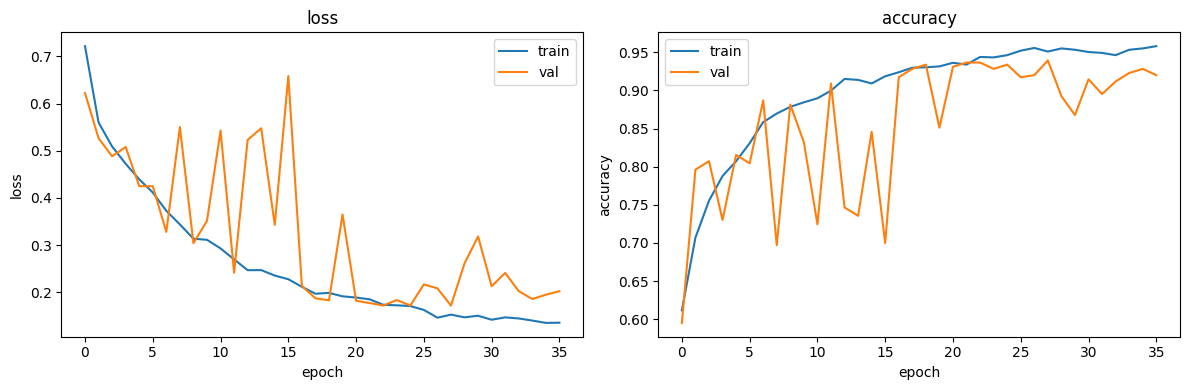

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist.history["loss"], label="train")
ax[0].plot(hist.history["val_loss"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss"); ax[0].set_title("loss"); ax[0].legend()

ax[1].plot(hist.history["accuracy"], label="train")
ax[1].plot(hist.history["val_accuracy"], label="val")
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy"); ax[1].set_title("accuracy"); ax[1].legend()
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye03_train_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Overfitting analysis

We compare **end-of-training train vs val accuracy** and look at the gap trajectory.

best val_loss at epoch 27  (train_acc=0.9511, val_acc=0.9394)


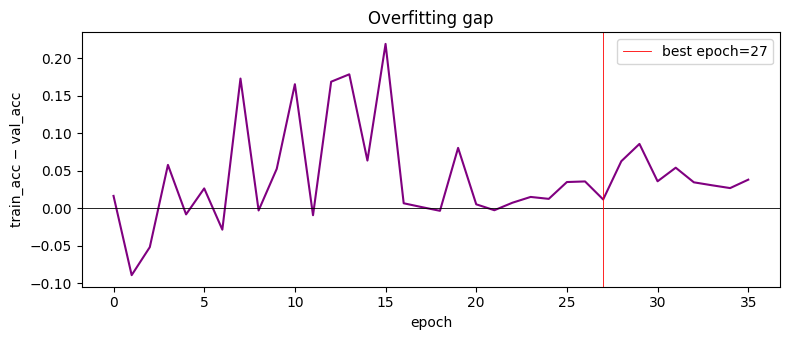

Comment: a gap that stays small (≲ 0.05) means dropout is doing its job; if it widens, increase dropout or augmentation in Notebook 05.


In [6]:
best_epoch = int(np.argmin(hist.history["val_loss"]))
print(f"best val_loss at epoch {best_epoch}  "
      f"(train_acc={hist.history['accuracy'][best_epoch]:.4f}, "
      f"val_acc={hist.history['val_accuracy'][best_epoch]:.4f})")

gap = np.array(hist.history["accuracy"]) - np.array(hist.history["val_accuracy"])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(gap, color="purple")
ax.axhline(0, color="k", lw=0.6); ax.axvline(best_epoch, color="r", lw=0.6, label=f"best epoch={best_epoch}")
ax.set_xlabel("epoch"); ax.set_ylabel("train_acc − val_acc"); ax.set_title("Overfitting gap")
ax.legend(); plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye03_overfit_gap.png", dpi=120, bbox_inches="tight")
plt.show()
print("Comment: a gap that stays small (≲ 0.05) means dropout is doing its job; if it widens, increase dropout or augmentation in Notebook 05.")

## 6. Test-set evaluation — Accuracy / Precision / Recall / F1 / Confusion / ROC

TEST  acc=0.8956  prec=0.8889  rec=0.9081  f1=0.8984  auc=0.9571

              precision    recall  f1-score   support

      closed     0.9029    0.8827    0.8927       179
        open     0.8889    0.9081    0.8984       185

    accuracy                         0.8956       364
   macro avg     0.8959    0.8954    0.8955       364
weighted avg     0.8958    0.8956    0.8956       364



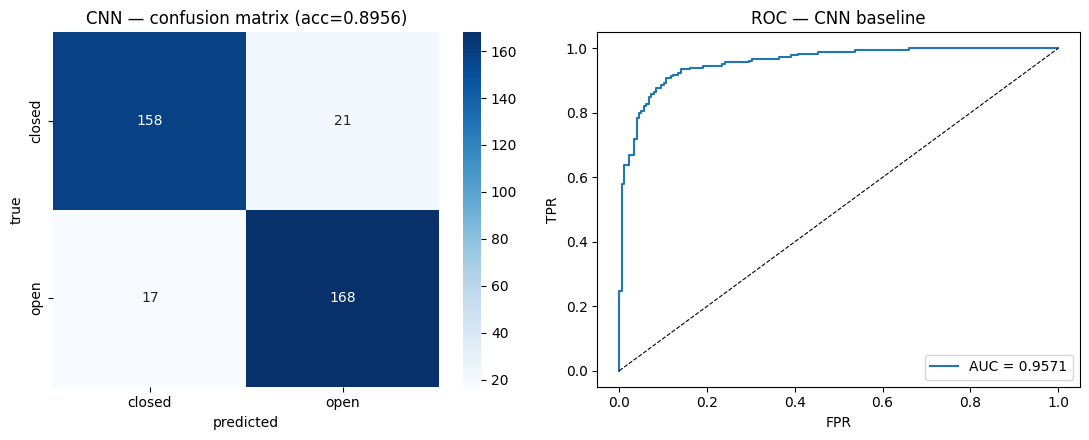

In [7]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, auc, classification_report)
import seaborn as sns

probs = model.predict(X_te, verbose=0)
y_pred = probs.argmax(axis=1)
acc = (y_pred == y_te).mean()
prec = precision_score(y_te, y_pred); rec = recall_score(y_te, y_pred); f1 = f1_score(y_te, y_pred)
fpr, tpr, _ = roc_curve(y_te, probs[:, 1])
roc_auc = auc(fpr, tpr)
print(f"TEST  acc={acc:.4f}  prec={prec:.4f}  rec={rec:.4f}  f1={f1:.4f}  auc={roc_auc:.4f}\n")
print(classification_report(y_te, y_pred, target_names=["closed", "open"], digits=4))

cm = confusion_matrix(y_te, y_pred)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["closed", "open"], yticklabels=["closed", "open"], ax=ax[0])
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("true"); ax[0].set_title(f"CNN — confusion matrix (acc={acc:.4f})")
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
ax[1].plot([0, 1], [0, 1], "k--", lw=0.8)
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title("ROC — CNN baseline"); ax[1].legend()
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eye03_cm_and_roc.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Misclassifications grid

Visualizing failures tells you *what kind* of image confuses the model — much more informative than aggregate metrics alone.

38 test mistakes out of 364 (10.4%)


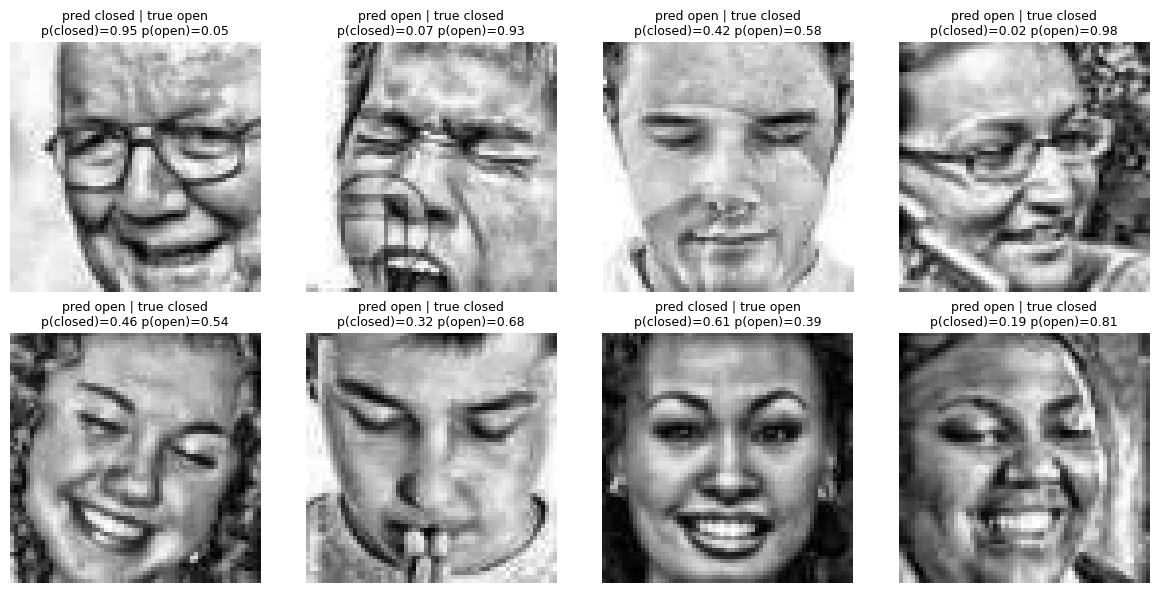

In [8]:
mis = np.where(y_pred != y_te)[0]
print(f"{len(mis)} test mistakes out of {len(y_te)} ({len(mis)/len(y_te)*100:.1f}%)")
if len(mis):
    n = min(8, len(mis))
    pick = np.random.RandomState(SEED).choice(mis, size=n, replace=False)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    names = ["closed", "open"]
    for ax, idx in zip(axes.ravel(), pick):
        ax.imshow(X_te[idx, ..., 0], cmap="gray")
        ax.set_title(f"pred {names[y_pred[idx]]} | true {names[y_te[idx]]}\n"
                     f"p(closed)={probs[idx,0]:.2f} p(open)={probs[idx,1]:.2f}", fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(ROOT / "artifacts" / "eye03_misclassifications.png", dpi=120, bbox_inches="tight")
    plt.show()

## 8. Save model + metrics for downstream notebooks

In [9]:
# Save Keras model
model.save(str(ROOT / "artifacts" / "eye03_cnn_baseline.keras"))

results = {
    "model": "cnn_baseline_from_scratch",
    "input_shape": list(IMG) + [1],
    "preprocessing": "gray+CLAHE",
    "n_params": int(model.count_params()),
    "epochs_trained": int(len(hist.history["loss"])),
    "best_epoch": best_epoch,
    "train_seconds": float(train_secs),
    "accuracy": float(acc),
    "precision": float(prec),
    "recall": float(rec),
    "f1": float(f1),
    "auc": float(roc_auc),
    "confusion_matrix": cm.tolist(),
    "train_history": {k: [float(v) for v in vs] for k, vs in hist.history.items()},
}
with open(ROOT / "artifacts" / "eye03_cnn_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved: artifacts/eye03_cnn_baseline.keras  ({model.count_params():,} params)")
print(f"Saved: artifacts/eye03_cnn_results.json")

Saved: artifacts/eye03_cnn_baseline.keras  (25,778 params)
Saved: artifacts/eye03_cnn_results.json


## Summary

We have a small **from-scratch** CNN (~75 K params, no pretrained weights) trained on the exact same split as the classical baseline. The next notebooks expand the comparison:

- `04_eye_transfer_learning.ipynb` — same task with MobileNetV3-Small / MobileNetV2 ImageNet weights, to quantify how much accuracy the from-scratch model loses by *not* using transfer learning.
- `05_eye_improved_experiments.ipynb` — controlled studies (augmentation, color space, distortion robustness, lightweight variants).